# Mel Local Gaussian Multiclass EDA

EDA-first notebook for multiclass contact classification. It keeps the old global Mel Gaussian baseline, then adds local 3x3 Mel Gaussian, band/time statistics, burstness features, and nearest-prototype multiclass diagnostics before optional CPU XGBoost.

In [1]:
from pathlib import Path

# Kaggle CPU EDA config.
# Set MAX_SAMPLES=80 for a quick smoke run; keep 0 for the full released dataset.
DATA_ROOT = Path("/kaggle/input/datasets/duyem54/visual-audio/dataset")
OUTPUT_DIR = Path("/kaggle/working/mel_local_gaussian_multiclass_eda")
MAX_SAMPLES = 0

TARGET_SR = 16000
WINDOW_SEC = 0.8
N_FFT = 1024
HOP_LENGTH = 256
N_MELS = 128
CROP_MODE = "energy"
WEIGHT_MODE = "positive_shift"
NORMALIZE_MODE = "positive_shift"  # "positive_shift" or "cmvn_positive_shift"
LOCAL_GRID = (3, 3)  # frequency bands x time bands
DISTANCE_METRICS = ("bhat", "w2")
SEED = 42
AUDIO_ONLY_INDEX = False

# EDA-first. Switch to True only after the diagnostics look worth training.
TRAIN_XGBOOST = False

In [2]:
from __future__ import annotations

import json
import math
import wave
from dataclasses import dataclass
from pathlib import Path
from typing import Iterable

import numpy as np
import pandas as pd

try:
    from IPython.display import Image, display
except Exception:
    Image = None
    display = print

LABELS = ("ambient", "leaf", "trunk", "twig")
LABEL_TO_ID = {label: idx for idx, label in enumerate(LABELS)}
ID_TO_LABEL = {idx: label for label, idx in LABEL_TO_ID.items()}
SPLITS = ("audio_visual_dataset_default", "audio_visual_dataset_robo_default")


@dataclass(frozen=True)
class FeatureConfig:
    target_sr: int = TARGET_SR
    window_sec: float = WINDOW_SEC
    n_fft: int = N_FFT
    hop_length: int = HOP_LENGTH
    n_mels: int = N_MELS
    crop_mode: str = CROP_MODE
    weight_mode: str = WEIGHT_MODE
    normalize_mode: str = NORMALIZE_MODE
    local_grid: tuple[int, int] = LOCAL_GRID
    seed: int = SEED


def tqdm_iter(iterable: Iterable, **kwargs):
    try:
        from tqdm.auto import tqdm

        return tqdm(iterable, **kwargs)
    except Exception:
        return iterable


def build_index(data_root: Path, skip_missing_files: bool = True, require_image: bool = True) -> pd.DataFrame:
    rows = []
    skipped = 0
    for split_name in SPLITS:
        split_dir = data_root / split_name
        csv_path = split_dir / "dataset.csv"
        if not csv_path.exists():
            continue
        frame = pd.read_csv(csv_path)
        for item in frame.to_dict("records"):
            audio_path = split_dir / str(item["audio_file"])
            image_path = split_dir / str(item.get("image_file", ""))
            audio_exists = audio_path.exists()
            image_exists = image_path.exists() if item.get("image_file") else False
            exists = audio_exists and (image_exists or not require_image)
            if skip_missing_files and not exists:
                skipped += 1
                continue
            label = str(item["category"])
            if label not in LABEL_TO_ID:
                skipped += 1
                continue
            rows.append(
                {
                    "split_name": split_name,
                    "split_role": "train" if split_name == SPLITS[0] else "val",
                    "audio_path": str(audio_path),
                    "image_path": str(image_path),
                    "label": label,
                    "label_id": LABEL_TO_ID[label],
                }
            )
    index = pd.DataFrame(rows)
    index.attrs["skipped_rows"] = skipped
    return index


def limit_index(index: pd.DataFrame, max_samples: int, seed: int) -> pd.DataFrame:
    if max_samples <= 0 or len(index) <= max_samples:
        return index.reset_index(drop=True)
    rng = np.random.default_rng(seed)
    parts = []
    per_split = max(1, max_samples // max(1, index["split_role"].nunique()))
    selected = set()
    for _, split_frame in index.groupby("split_role", sort=False):
        take = min(len(split_frame), per_split)
        chosen = rng.choice(split_frame.index.to_numpy(), size=take, replace=False)
        selected.update(int(x) for x in chosen)
        parts.append(index.loc[chosen])
    limited = pd.concat(parts, ignore_index=True)
    if len(limited) < max_samples:
        remaining = index.drop(index=list(selected), errors="ignore")
        if not remaining.empty:
            take = min(max_samples - len(limited), len(remaining))
            chosen = rng.choice(remaining.index.to_numpy(), size=take, replace=False)
            limited = pd.concat([limited, index.loc[chosen]], ignore_index=True)
    return limited.reset_index(drop=True)


def load_wav_stdlib(path: Path) -> tuple[np.ndarray, int]:
    with wave.open(str(path), "rb") as wav:
        channels = wav.getnchannels()
        sample_rate = wav.getframerate()
        sample_width = wav.getsampwidth()
        frames = wav.readframes(wav.getnframes())
    if sample_width == 1:
        data = np.frombuffer(frames, dtype=np.uint8).astype(np.float32)
        data = (data - 128.0) / 128.0
    elif sample_width == 2:
        data = np.frombuffer(frames, dtype="<i2").astype(np.float32) / 32768.0
    elif sample_width == 3:
        raw = np.frombuffer(frames, dtype=np.uint8).reshape(-1, 3)
        signed = raw[:, 0].astype(np.int32) | (raw[:, 1].astype(np.int32) << 8) | (raw[:, 2].astype(np.int32) << 16)
        signed = np.where(signed & 0x800000, signed | ~0xFFFFFF, signed)
        data = signed.astype(np.float32) / 8388608.0
    elif sample_width == 4:
        data = np.frombuffer(frames, dtype="<i4").astype(np.float32) / 2147483648.0
    else:
        raise ValueError(f"Unsupported WAV sample width: {sample_width} bytes")
    if channels > 1:
        data = data.reshape(-1, channels).mean(axis=1)
    return data.astype(np.float32), int(sample_rate)


def load_wav_mono(path: str | Path) -> tuple[np.ndarray, int]:
    path = Path(path)
    try:
        import soundfile as sf

        audio, sample_rate = sf.read(path, dtype="float32", always_2d=True)
        return audio.mean(axis=1).astype(np.float32), int(sample_rate)
    except Exception:
        pass
    try:
        import torchaudio

        waveform, sample_rate = torchaudio.load(str(path))
        return waveform.mean(dim=0).detach().cpu().numpy().astype(np.float32), int(sample_rate)
    except Exception:
        pass
    return load_wav_stdlib(path)


def resample_audio(audio: np.ndarray, orig_sr: int, target_sr: int) -> np.ndarray:
    if orig_sr == target_sr:
        return audio.astype(np.float32, copy=False)
    try:
        from scipy.signal import resample_poly

        gcd = math.gcd(orig_sr, target_sr)
        return resample_poly(audio, target_sr // gcd, orig_sr // gcd).astype(np.float32)
    except Exception:
        target_len = max(1, int(round(len(audio) * target_sr / orig_sr)))
        old_x = np.linspace(0.0, 1.0, num=len(audio), endpoint=False)
        new_x = np.linspace(0.0, 1.0, num=target_len, endpoint=False)
        return np.interp(new_x, old_x, audio).astype(np.float32)


def crop_or_pad(audio: np.ndarray, target_samples: int, mode: str, rng: np.random.Generator) -> np.ndarray:
    if len(audio) < target_samples:
        return np.pad(audio, (0, target_samples - len(audio))).astype(np.float32)
    if len(audio) == target_samples:
        return audio.astype(np.float32, copy=False)
    max_start = len(audio) - target_samples
    if mode == "random":
        start = int(rng.integers(0, max_start + 1))
    elif mode == "energy":
        squared = audio.astype(np.float64) ** 2
        cumsum = np.concatenate([[0.0], np.cumsum(squared)])
        energy = cumsum[target_samples:] - cumsum[:-target_samples]
        start = int(np.argmax(energy))
    else:
        start = max_start // 2
    return audio[start : start + target_samples].astype(np.float32)


def load_audio_window(path: str | Path, cfg: FeatureConfig, rng: np.random.Generator) -> np.ndarray:
    audio, sample_rate = load_wav_mono(path)
    audio = resample_audio(audio, sample_rate, cfg.target_sr)
    return crop_or_pad(audio, int(round(cfg.target_sr * cfg.window_sec)), cfg.crop_mode, rng)


def stft_power_spectrogram(audio: np.ndarray, cfg: FeatureConfig) -> np.ndarray:
    if len(audio) < cfg.n_fft:
        audio = np.pad(audio, (0, cfg.n_fft - len(audio)))
    frame_count = 1 + max(0, (len(audio) - cfg.n_fft) // cfg.hop_length)
    starts = np.arange(frame_count) * cfg.hop_length
    window = np.hanning(cfg.n_fft).astype(np.float32)
    frames = np.stack([audio[start : start + cfg.n_fft] for start in starts], axis=0)
    spectrum = np.fft.rfft(frames * window[None, :], n=cfg.n_fft, axis=1)
    return (np.abs(spectrum) ** 2).astype(np.float32).T


def hz_to_mel(freq):
    return 2595.0 * np.log10(1.0 + np.asarray(freq) / 700.0)


def mel_to_hz(mel):
    return 700.0 * (10.0 ** (np.asarray(mel) / 2595.0) - 1.0)


def mel_filter_bank(sample_rate: int, n_fft: int, n_mels: int) -> np.ndarray:
    mel_points = np.linspace(hz_to_mel(0.0), hz_to_mel(sample_rate / 2.0), n_mels + 2)
    hz_points = mel_to_hz(mel_points)
    bins = np.floor((n_fft + 1) * hz_points / sample_rate).astype(int)
    max_bin = n_fft // 2
    bins = np.clip(bins, 0, max_bin)
    filters = np.zeros((n_mels, max_bin + 1), dtype=np.float32)
    for mel_idx in range(1, n_mels + 1):
        left, center, right = bins[mel_idx - 1], bins[mel_idx], bins[mel_idx + 1]
        center = max(center, left + 1)
        right = min(max(right, center + 1), max_bin)
        for freq_bin in range(left, center):
            filters[mel_idx - 1, freq_bin] = (freq_bin - left) / max(1, center - left)
        for freq_bin in range(center, right + 1):
            filters[mel_idx - 1, freq_bin] = (right - freq_bin) / max(1, right - center)
    enorm = 2.0 / np.maximum(1e-10, hz_points[2 : n_mels + 2] - hz_points[:n_mels])
    return filters * enorm[:, None]


def power_to_db(power: np.ndarray, amin: float = 1e-10) -> np.ndarray:
    return (10.0 * np.log10(np.maximum(power, amin))).astype(np.float32)


def mel_spectrogram(audio: np.ndarray, cfg: FeatureConfig) -> np.ndarray:
    power = stft_power_spectrogram(audio, cfg)
    mel_power = mel_filter_bank(cfg.target_sr, cfg.n_fft, cfg.n_mels) @ power
    return power_to_db(mel_power)


def normalize_map(feature_map: np.ndarray, mode: str) -> np.ndarray:
    values = np.nan_to_num(feature_map.astype(np.float64), nan=0.0, posinf=0.0, neginf=0.0)
    if mode == "cmvn_positive_shift":
        values = (values - values.mean()) / (values.std() + 1e-8)
    values = values - values.min()
    if values.max() > 0:
        values = values / values.max()
    return values.astype(np.float32)


def map_to_weights(feature_map: np.ndarray, mode: str = "positive_shift") -> np.ndarray:
    values = np.nan_to_num(feature_map.astype(np.float64), nan=0.0, posinf=0.0, neginf=0.0)
    if mode == "absolute":
        weights = np.abs(values)
    elif mode == "softmax":
        shifted = np.clip(values - np.max(values), -60.0, 60.0)
        weights = np.exp(shifted)
    else:
        weights = values - np.min(values)
    if not np.isfinite(weights).all() or float(weights.sum()) <= 1e-12:
        weights = np.ones_like(values, dtype=np.float64)
    weights = weights + 1e-12
    return weights / weights.sum()


def entropy_from_weights(weights: np.ndarray) -> float:
    flat = weights.reshape(-1)
    return float(-np.sum(flat * np.log(flat + 1e-12)))

In [3]:
def regularize_cov(cov: np.ndarray, eps: float = 1e-6) -> np.ndarray:
    cov = 0.5 * (cov + cov.T)
    eigvals = np.linalg.eigvalsh(cov)
    min_eig = float(eigvals.min())
    if min_eig < eps:
        cov = cov + np.eye(cov.shape[0]) * (eps - min_eig)
    return cov


def weighted_gaussian_stats(feature_map: np.ndarray, prefix: str) -> dict:
    weights = map_to_weights(feature_map, "positive_shift")
    freq_bins, time_bins = weights.shape
    freq_coord = np.linspace(0.0, 1.0, freq_bins, dtype=np.float64)[:, None]
    time_coord = np.linspace(0.0, 1.0, time_bins, dtype=np.float64)[None, :]
    mu_freq = float(np.sum(weights * freq_coord))
    mu_time = float(np.sum(weights * time_coord))
    df = freq_coord - mu_freq
    dt = time_coord - mu_time
    cov_ff = float(np.sum(weights * df * df) + 1e-6)
    cov_tt = float(np.sum(weights * dt * dt) + 1e-6)
    cov_ft = float(np.sum(weights * df * dt))
    cov = regularize_cov(np.array([[cov_ff, cov_ft], [cov_ft, cov_tt]], dtype=np.float64))
    det = max(float(np.linalg.det(cov)), 1e-12)
    return {
        f"{prefix}_mu_freq": mu_freq,
        f"{prefix}_mu_time": mu_time,
        f"{prefix}_cov_ff": float(cov[0, 0]),
        f"{prefix}_cov_ft": float(cov[0, 1]),
        f"{prefix}_cov_tt": float(cov[1, 1]),
        f"{prefix}_std_freq": float(math.sqrt(max(cov[0, 0], 0.0))),
        f"{prefix}_std_time": float(math.sqrt(max(cov[1, 1], 0.0))),
        f"{prefix}_entropy": entropy_from_weights(weights),
        f"{prefix}_energy": float(np.square(feature_map).mean()),
        f"{prefix}_peak": float(feature_map.max()),
        f"{prefix}_mean": float(feature_map.mean()),
        f"{prefix}_std": float(feature_map.std()),
        f"{prefix}_logdet": float(math.log(det)),
    }


def split_slices(length: int, parts: int) -> list[slice]:
    edges = np.linspace(0, length, parts + 1).round().astype(int)
    slices = []
    for idx in range(parts):
        start, end = int(edges[idx]), int(edges[idx + 1])
        if end <= start:
            end = min(length, start + 1)
        slices.append(slice(start, end))
    return slices


def local_gaussian_features(feature_map: np.ndarray, cfg: FeatureConfig) -> dict:
    freq_parts, time_parts = cfg.local_grid
    rows = {}
    freq_slices = split_slices(feature_map.shape[0], freq_parts)
    time_slices = split_slices(feature_map.shape[1], time_parts)
    for fi, freq_slice in enumerate(freq_slices):
        for ti, time_slice in enumerate(time_slices):
            patch = feature_map[freq_slice, time_slice]
            rows.update(weighted_gaussian_stats(patch, f"local_f{fi}_t{ti}"))
    return rows


def band_time_stats(feature_map: np.ndarray, cfg: FeatureConfig) -> dict:
    rows = {}
    freq_slices = split_slices(feature_map.shape[0], cfg.local_grid[0])
    time_slices = split_slices(feature_map.shape[1], cfg.local_grid[1])
    for idx, freq_slice in enumerate(freq_slices):
        patch = feature_map[freq_slice, :]
        weights = map_to_weights(patch, "positive_shift")
        rows.update(
            {
                f"band_f{idx}_mean": float(patch.mean()),
                f"band_f{idx}_std": float(patch.std()),
                f"band_f{idx}_max": float(patch.max()),
                f"band_f{idx}_entropy": entropy_from_weights(weights),
                f"band_f{idx}_energy_share": float(np.square(patch).sum() / (np.square(feature_map).sum() + 1e-12)),
            }
        )
    for idx, time_slice in enumerate(time_slices):
        patch = feature_map[:, time_slice]
        weights = map_to_weights(patch, "positive_shift")
        rows.update(
            {
                f"time_t{idx}_mean": float(patch.mean()),
                f"time_t{idx}_std": float(patch.std()),
                f"time_t{idx}_max": float(patch.max()),
                f"time_t{idx}_entropy": entropy_from_weights(weights),
                f"time_t{idx}_energy_share": float(np.square(patch).sum() / (np.square(feature_map).sum() + 1e-12)),
            }
        )
    return rows


def burstness_features(feature_map: np.ndarray) -> dict:
    temporal_energy = np.square(feature_map).mean(axis=0)
    spectral_energy = np.square(feature_map).mean(axis=1)
    temporal_norm = temporal_energy / (temporal_energy.sum() + 1e-12)
    threshold = temporal_energy.mean() + temporal_energy.std()
    return {
        "burst_temporal_peak": float(temporal_energy.max()),
        "burst_temporal_mean": float(temporal_energy.mean()),
        "burst_max_to_mean": float(temporal_energy.max() / (temporal_energy.mean() + 1e-12)),
        "burst_peak_count": int(np.sum(temporal_energy > threshold)),
        "burst_temporal_concentration": float(np.sum(np.sort(temporal_norm)[-max(1, len(temporal_norm) // 5) :])),
        "burst_spectral_peak_bin": float(np.argmax(spectral_energy) / max(1, len(spectral_energy) - 1)),
        "burst_spectral_concentration": float(np.max(spectral_energy) / (spectral_energy.sum() + 1e-12)),
    }


def extract_feature_row(item: dict, cfg: FeatureConfig, rng: np.random.Generator) -> dict:
    audio = load_audio_window(item["audio_path"], cfg, rng)
    mel = mel_spectrogram(audio, cfg)
    norm_mel = normalize_map(mel, cfg.normalize_mode)
    row = {
        "split_name": item["split_name"],
        "split_role": item["split_role"],
        "audio_path": item["audio_path"],
        "label": item["label"],
        "label_id": item["label_id"],
    }
    row.update(weighted_gaussian_stats(norm_mel, "global"))
    row.update(local_gaussian_features(norm_mel, cfg))
    row.update(band_time_stats(norm_mel, cfg))
    row.update(burstness_features(norm_mel))
    return row


def build_feature_frame(index: pd.DataFrame, cfg: FeatureConfig) -> tuple[pd.DataFrame, list[dict]]:
    rng = np.random.default_rng(cfg.seed)
    rows = []
    failures = []
    for item in tqdm_iter(index.to_dict("records"), desc="mel local gaussian EDA", leave=False):
        try:
            rows.append(extract_feature_row(item, cfg, rng))
        except Exception as exc:
            failures.append({"audio_path": item.get("audio_path"), "error": repr(exc)})
    return pd.DataFrame(rows), failures

In [4]:
def gaussian_from_row(row: pd.Series, prefix: str) -> tuple[np.ndarray, np.ndarray]:
    mu = np.array([row[f"{prefix}_mu_freq"], row[f"{prefix}_mu_time"]], dtype=np.float64)
    cov = np.array(
        [
            [row[f"{prefix}_cov_ff"], row[f"{prefix}_cov_ft"]],
            [row[f"{prefix}_cov_ft"], row[f"{prefix}_cov_tt"]],
        ],
        dtype=np.float64,
    )
    return mu, regularize_cov(cov)


def bhattacharyya_distance(mu_a: np.ndarray, cov_a: np.ndarray, mu_b: np.ndarray, cov_b: np.ndarray) -> float:
    cov_mean = regularize_cov(0.5 * (cov_a + cov_b))
    diff = mu_b - mu_a
    sign_mean, logdet_mean = np.linalg.slogdet(cov_mean)
    sign_a, logdet_a = np.linalg.slogdet(regularize_cov(cov_a))
    sign_b, logdet_b = np.linalg.slogdet(regularize_cov(cov_b))
    if sign_mean <= 0 or sign_a <= 0 or sign_b <= 0:
        return float("inf")
    mahal = 0.125 * float(diff.T @ np.linalg.inv(cov_mean) @ diff)
    det_term = 0.5 * (logdet_mean - 0.5 * (logdet_a + logdet_b))
    return float(max(mahal + det_term, 0.0))


def spd_sqrtm(matrix: np.ndarray) -> np.ndarray:
    eigvals, eigvecs = np.linalg.eigh(regularize_cov(matrix))
    eigvals = np.clip(eigvals, 1e-12, None)
    return (eigvecs * np.sqrt(eigvals)) @ eigvecs.T


def wasserstein2_distance(mu_a: np.ndarray, cov_a: np.ndarray, mu_b: np.ndarray, cov_b: np.ndarray) -> float:
    sqrt_a = spd_sqrtm(cov_a)
    middle = spd_sqrtm(sqrt_a @ regularize_cov(cov_b) @ sqrt_a)
    mean_term = float(np.sum((mu_a - mu_b) ** 2))
    cov_term = float(np.trace(regularize_cov(cov_a) + regularize_cov(cov_b) - 2.0 * middle))
    return float(math.sqrt(max(mean_term + cov_term, 0.0)))


def gaussian_prefixes(frame: pd.DataFrame) -> list[str]:
    prefixes = []
    for col in frame.columns:
        if col.endswith("_mu_freq"):
            prefix = col[: -len("_mu_freq")]
            if f"{prefix}_cov_ff" in frame.columns:
                prefixes.append(prefix)
    return prefixes


def fit_prototypes(frame: pd.DataFrame, prefixes: list[str]) -> dict:
    prototypes = {}
    train = frame[frame["split_role"] == "train"].reset_index(drop=True)
    for label in LABELS:
        part = train[train["label"] == label]
        if part.empty:
            continue
        prototypes[label] = {}
        for prefix in prefixes:
            mus, covs = [], []
            for _, row in part.iterrows():
                mu, cov = gaussian_from_row(row, prefix)
                mus.append(mu)
                covs.append(cov)
            mu_stack = np.stack(mus)
            mean_mu = mu_stack.mean(axis=0)
            within_cov = np.stack(covs).mean(axis=0)
            between_cov = np.cov(mu_stack.T, bias=True) if len(mu_stack) > 1 else np.zeros((2, 2))
            prototypes[label][prefix] = {"mu": mean_mu, "cov": regularize_cov(within_cov + between_cov)}
    return prototypes


def add_distance_features(frame: pd.DataFrame, prototypes: dict, prefixes: list[str]) -> pd.DataFrame:
    output = frame.copy()
    for prefix in prefixes:
        for label in LABELS:
            if label in prototypes:
                output[f"{prefix}_bhat_to_{label}"] = np.nan
                output[f"{prefix}_w2_to_{label}"] = np.nan
    for idx, row in output.iterrows():
        for prefix in prefixes:
            mu, cov = gaussian_from_row(row, prefix)
            for label, proto_by_prefix in prototypes.items():
                proto = proto_by_prefix[prefix]
                output.at[idx, f"{prefix}_bhat_to_{label}"] = bhattacharyya_distance(mu, cov, proto["mu"], proto["cov"])
                output.at[idx, f"{prefix}_w2_to_{label}"] = wasserstein2_distance(mu, cov, proto["mu"], proto["cov"])
    return output


def distance_columns_for_group(frame: pd.DataFrame, prefixes: list[str], metric: str) -> list[str]:
    return [f"{prefix}_{metric}_to_{label}" for prefix in prefixes for label in LABELS if f"{prefix}_{metric}_to_{label}" in frame.columns]


def nearest_prototype_predict(frame: pd.DataFrame, prefixes: list[str], metric: str = "bhat") -> np.ndarray:
    preds = []
    for _, row in frame.iterrows():
        scores = {}
        for label in LABELS:
            cols = [f"{prefix}_{metric}_to_{label}" for prefix in prefixes if f"{prefix}_{metric}_to_{label}" in frame.columns]
            scores[label] = float(np.mean([row[col] for col in cols]))
        preds.append(LABEL_TO_ID[min(scores, key=scores.get)])
    return np.asarray(preds, dtype=int)


def classification_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

    report = classification_report(
        y_true,
        y_pred,
        labels=list(range(len(LABELS))),
        target_names=LABELS,
        output_dict=True,
        zero_division=0,
    )
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "weighted_f1": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
        "confusion_matrix": confusion_matrix(y_true, y_pred, labels=list(range(len(LABELS)))).tolist(),
        "classification_report": report,
    }


def evaluate_nearest_prototypes(frame: pd.DataFrame, prefix_groups: dict[str, list[str]]) -> pd.DataFrame:
    rows = []
    val = frame[frame["split_role"] == "val"].reset_index(drop=True)
    if val.empty:
        val = frame.reset_index(drop=True)
    y_true = val["label_id"].to_numpy()
    for group_name, prefixes in prefix_groups.items():
        for metric in DISTANCE_METRICS:
            y_pred = nearest_prototype_predict(val, prefixes, metric)
            metrics = classification_metrics(y_true, y_pred)
            rows.append(
                {
                    "feature_group": group_name,
                    "distance_metric": metric,
                    "accuracy": metrics["accuracy"],
                    "macro_f1": metrics["macro_f1"],
                    "weighted_f1": metrics["weighted_f1"],
                    "confusion_matrix": metrics["confusion_matrix"],
                }
            )
    return pd.DataFrame(rows)


cfg = FeatureConfig()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
index = build_index(DATA_ROOT, skip_missing_files=True, require_image=not AUDIO_ONLY_INDEX)
index = limit_index(index, MAX_SAMPLES, SEED)
print(f"Rows in index: {len(index)} | skipped: {index.attrs.get('skipped_rows', 0)}")

features, failures = build_feature_frame(index, cfg)
if features.empty:
    raise RuntimeError("No features were extracted. Check DATA_ROOT and audio files.")

prefixes = gaussian_prefixes(features)
global_prefixes = ["global"]
local_prefixes = [prefix for prefix in prefixes if prefix.startswith("local_")]
all_prefixes = [*global_prefixes, *local_prefixes]
prototypes = fit_prototypes(features, all_prefixes)
features = add_distance_features(features, prototypes, all_prefixes)

prefix_groups = {
    "global": global_prefixes,
    "local_3x3": local_prefixes,
    "global_plus_local_3x3": all_prefixes,
}
prototype_eval = evaluate_nearest_prototypes(features, prefix_groups)

feature_path = OUTPUT_DIR / "features.csv"
eval_path = OUTPUT_DIR / "nearest_prototype_eval.csv"
summary_path = OUTPUT_DIR / "summary.json"
features.to_csv(feature_path, index=False)
prototype_eval.to_csv(eval_path, index=False)
summary = {
    "rows": int(len(features)),
    "train_rows": int((features["split_role"] == "train").sum()),
    "val_rows": int((features["split_role"] == "val").sum()),
    "labels": LABELS,
    "config": cfg.__dict__,
    "feature_groups": {key: value for key, value in prefix_groups.items()},
    "skipped_index_rows": int(index.attrs.get("skipped_rows", 0)),
    "failed_feature_rows": int(len(failures)),
    "outputs": {
        "features_csv": str(feature_path),
        "nearest_prototype_eval_csv": str(eval_path),
        "summary_json": str(summary_path),
    },
}
summary_path.write_text(json.dumps(summary, indent=2), encoding="utf-8")
if failures:
    (OUTPUT_DIR / "failures.json").write_text(json.dumps(failures, indent=2), encoding="utf-8")

display(prototype_eval.sort_values(["macro_f1", "accuracy"], ascending=False).round(4))
display(features.head())
print(json.dumps(summary, indent=2))

Rows in index: 12894 | skipped: 1


mel local gaussian EDA:   0%|          | 0/12894 [00:00<?, ?it/s]

,feature_group,distance_metric,accuracy,macro_f1,weighted_f1,confusion_matrix
0,global,bhat,0.5555,0.4170,0.5649,"[[898, 104, 42, 87], [22, 51, 116, 104], [82, ..."
1,global,w2,0.5347,0.3980,0.5469,"[[877, 98, 64, 92], [19, 51, 115, 108], [83, 3..."
5,global_plus_local_3x3,w2,0.4851,0.3858,0.5104,"[[748, 270, 84, 29], [59, 34, 137, 63], [108, ..."
4,global_plus_local_3x3,bhat,0.4968,0.3808,0.5136,"[[784, 204, 76, 67], [63, 31, 141, 58], [115, ..."
3,local_3x3,w2,0.4675,0.3791,0.4932,"[[715, 261, 129, 26], [70, 53, 123, 47], [124,..."
2,local_3x3,bhat,0.4811,0.3721,0.4978,"[[762, 193, 112, 64], [75, 41, 127, 50], [135,..."


,split_name,split_role,audio_path,label,label_id,global_mu_freq,global_mu_time,global_cov_ff,global_cov_ft,global_cov_tt,...,local_f2_t1_bhat_to_twig,local_f2_t1_w2_to_twig,local_f2_t2_bhat_to_ambient,local_f2_t2_w2_to_ambient,local_f2_t2_bhat_to_leaf,local_f2_t2_w2_to_leaf,local_f2_t2_bhat_to_trunk,local_f2_t2_w2_to_trunk,local_f2_t2_bhat_to_twig,local_f2_t2_w2_to_twig
0,audio_visual_dataset_default,train,/kaggle/input/datasets/duyem54/visual-audio/da...,ambient,0,0.299317,0.356525,0.104159,-0.010761,0.057683,...,0.588160,0.430239,0.621355,0.446294,0.705096,0.498852,0.694441,0.493601,0.714665,0.506031
1,audio_visual_dataset_default,train,/kaggle/input/datasets/duyem54/visual-audio/da...,ambient,0,0.329823,0.226139,0.115873,-0.024612,0.028258,...,0.497891,0.403270,0.003001,0.045499,0.008559,0.074601,0.010274,0.081584,0.010622,0.084332
2,audio_visual_dataset_default,train,/kaggle/input/datasets/duyem54/visual-audio/da...,ambient,0,0.157709,0.438744,0.021588,-0.006154,0.080583,...,0.009444,0.079416,0.316155,0.407691,0.337886,0.446517,0.359452,0.463126,0.340627,0.449949
3,audio_visual_dataset_default,train,/kaggle/input/datasets/duyem54/visual-audio/da...,ambient,0,0.133109,0.433909,0.019003,-0.001158,0.053128,...,1.955008,0.541021,0.541352,0.326923,0.613548,0.385656,0.609202,0.385053,0.621465,0.393031
4,audio_visual_dataset_default,train,/kaggle/input/datasets/duyem54/visual-audio/da...,ambient,0,0.390967,0.444204,0.113294,-0.000673,0.074942,...,0.358984,0.419535,0.133183,0.188653,0.157880,0.229604,0.155003,0.228226,0.161654,0.236055


{
  "rows": 12894,
  "train_rows": 10676,
  "val_rows": 2218,
  "labels": [
    "ambient",
    "leaf",
    "trunk",
    "twig"
  ],
  "config": {
    "target_sr": 16000,
    "window_sec": 0.8,
    "n_fft": 1024,
    "hop_length": 256,
    "n_mels": 128,
    "crop_mode": "energy",
    "weight_mode": "positive_shift",
    "normalize_mode": "positive_shift",
    "local_grid": [
      3,
      3
    ],
    "seed": 42
  },
  "feature_groups": {
    "global": [
      "global"
    ],
    "local_3x3": [
      "local_f0_t0",
      "local_f0_t1",
      "local_f0_t2",
      "local_f1_t0",
      "local_f1_t1",
      "local_f1_t2",
      "local_f2_t0",
      "local_f2_t1",
      "local_f2_t2"
    ],
    "global_plus_local_3x3": [
      "global",
      "local_f0_t0",
      "local_f0_t1",
      "local_f0_t2",
      "local_f1_t0",
      "local_f1_t1",
      "local_f1_t2",
      "local_f2_t0",
      "local_f2_t1",
      "local_f2_t2"
    ]
  },
  "skipped_index_rows": 1,
  "failed_feature_rows": 0,
  "

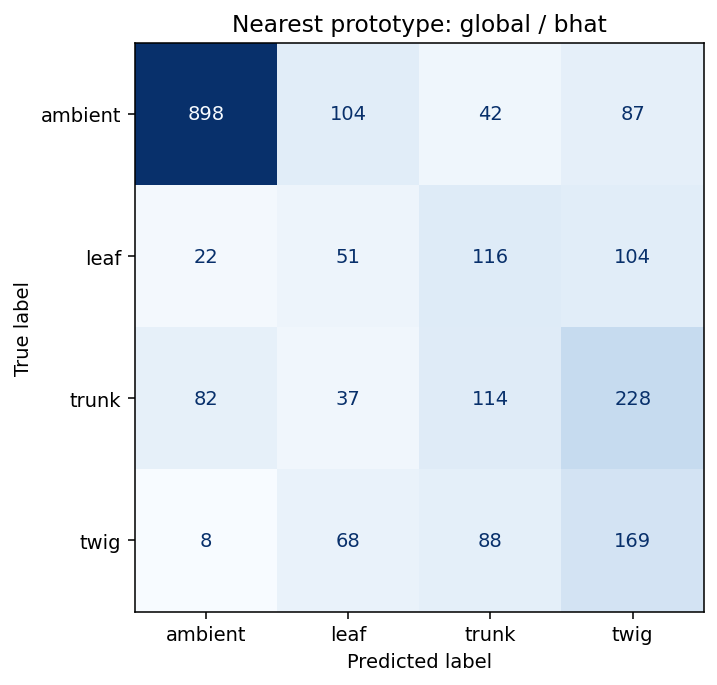

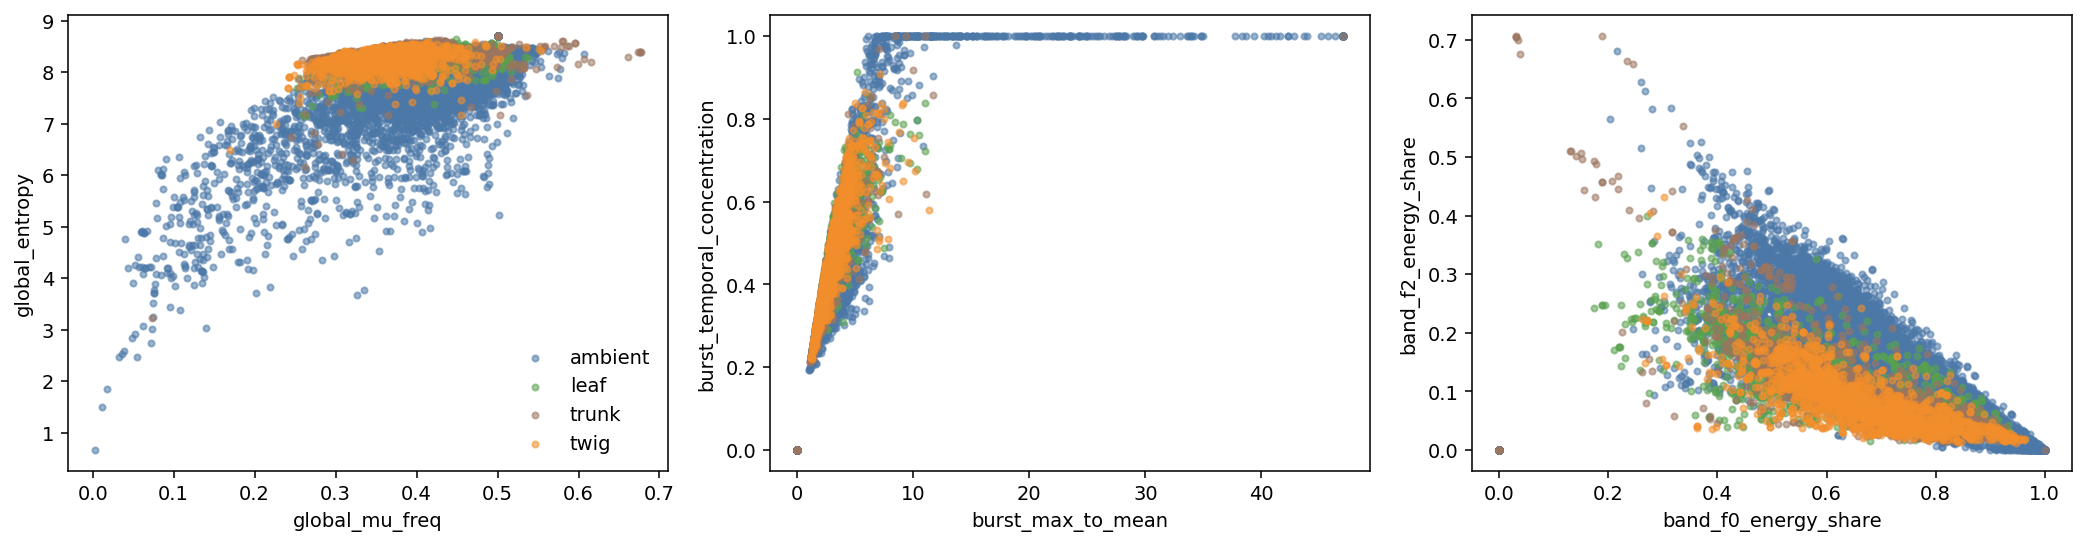

global_mu_freq  global_entropy  burst_max_to_mean  \
split_role label                                                        
train      ambient          0.4202          7.6303             3.1140   
           leaf             0.3971          8.2836             2.8968   
           trunk            0.3736          8.3186             2.4309   
           twig             0.3655          8.2510             2.9903   
val        ambient          0.4487          8.0264             2.5754   
           leaf             0.3581          8.2294             3.2005   
           trunk            0.3619          8.2690             2.5656   
           twig             0.3607          8.2361             3.1780   

                    burst_temporal_concentration  band_f0_energy_share  \
split_role label                                                         
train      ambient                        0.3623                0.6222   
           leaf                           0.4380                0.5731   
           trunk                          0.3800                0.6418   
           twig                           0.4507                0.6490   
val        ambient                        0.3292                0.5012   
           leaf                           0.4381                0.7166   
           trunk                          0.3802                0.7238   
           twig                           0.4575                0.6918   

                    band_f1_energy_share  band_f2_energy_share  \
split_role label                                                 
train      ambient                0.1355                0.1742   
           leaf                   0.2936                0.1333   
           trunk                  0.2456                0.1092   
           twig                   0.2621                0.0890   
val        ambient                0.2004                0.1968   
           leaf                   0.1995                0.0839   
           trunk                  0.1795                0.0967   
           twig                   0.2281                0.0801   

                    time_t0_energy_share  time_t1_energy_share  \
split_role label                                                 
train      ambient                0.3385                0.2690   
           leaf                   0.3479                0.2803   
           trunk                  0.3543                0.2910   
           twig                   0.3527                0.2789   
val        ambient                0.3125                0.2655   
           leaf                   0.3797                0.2888   
           trunk                  0.3575                0.2962   
           twig                   0.3373                0.2928   

                    time_t2_energy_share  
split_role label                          
train      ambient                0.3244  
           leaf                   0.3718  
           trunk                  0.3513  
           twig                   0.3684  
val        ambient                0.3203  
           leaf                   0.3315  
           trunk                  0.3463  
           twig                   0.3699

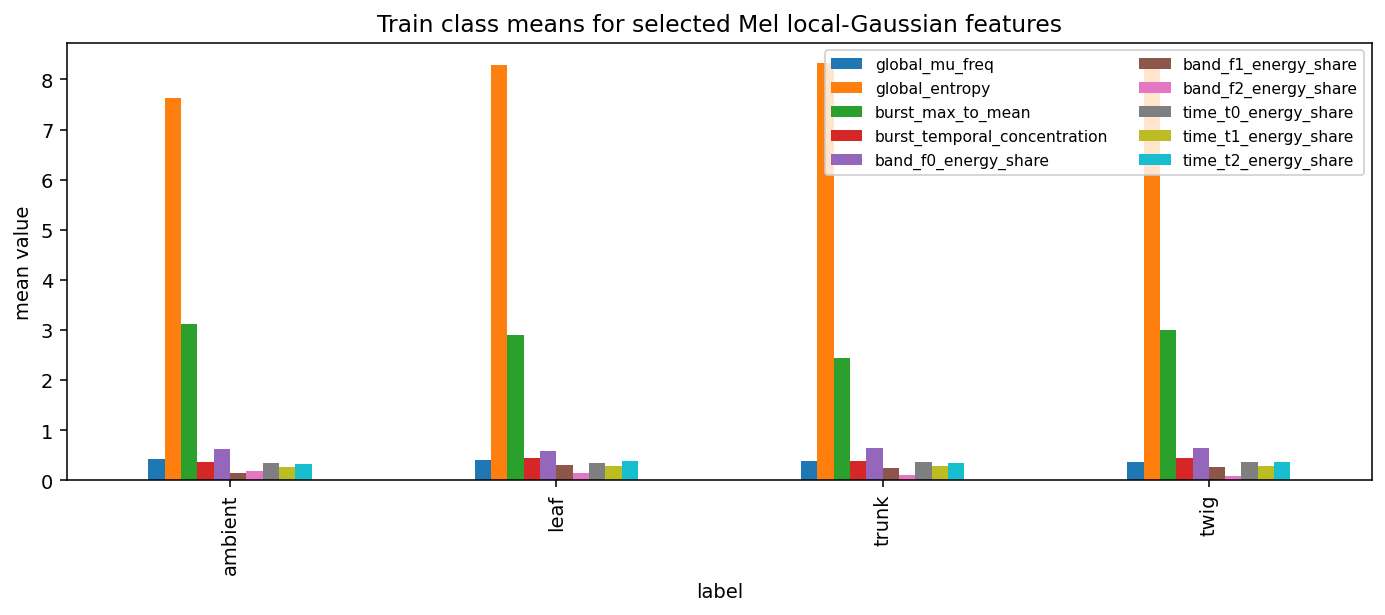

In [5]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay


def plot_confusion_for_best(eval_frame: pd.DataFrame, features: pd.DataFrame) -> None:
    best = eval_frame.sort_values(["macro_f1", "accuracy"], ascending=False).iloc[0]
    group = best["feature_group"]
    metric = best["distance_metric"]
    prefixes = prefix_groups[group]
    val = features[features["split_role"] == "val"].reset_index(drop=True)
    if val.empty:
        val = features.reset_index(drop=True)
    y_true = val["label_id"].to_numpy()
    y_pred = nearest_prototype_predict(val, prefixes, metric)
    fig, ax = plt.subplots(figsize=(5.5, 5), dpi=140)
    ConfusionMatrixDisplay.from_predictions(
        y_true,
        y_pred,
        labels=list(range(len(LABELS))),
        display_labels=LABELS,
        cmap="Blues",
        colorbar=False,
        ax=ax,
    )
    ax.set_title(f"Nearest prototype: {group} / {metric}")
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "nearest_prototype_best_confusion.png")
    display(fig)
    plt.close(fig)


def plot_selected_feature_scatter(features: pd.DataFrame) -> None:
    pairs = [
        ("global_mu_freq", "global_entropy"),
        ("burst_max_to_mean", "burst_temporal_concentration"),
        ("band_f0_energy_share", "band_f2_energy_share"),
    ]
    fig, axes = plt.subplots(1, len(pairs), figsize=(15, 4), dpi=140)
    colors = {"ambient": "#4c78a8", "leaf": "#59a14f", "trunk": "#9c755f", "twig": "#f28e2b"}
    for ax, (x_col, y_col) in zip(axes, pairs):
        for label in LABELS:
            part = features[features["label"] == label]
            ax.scatter(part[x_col], part[y_col], s=10, alpha=0.55, label=label, color=colors[label])
        ax.set_xlabel(x_col)
        ax.set_ylabel(y_col)
    axes[0].legend(frameon=False)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "selected_feature_scatter.png")
    display(fig)
    plt.close(fig)


def plot_group_feature_means(features: pd.DataFrame) -> None:
    selected = [
        "global_mu_freq",
        "global_entropy",
        "burst_max_to_mean",
        "burst_temporal_concentration",
        "band_f0_energy_share",
        "band_f1_energy_share",
        "band_f2_energy_share",
        "time_t0_energy_share",
        "time_t1_energy_share",
        "time_t2_energy_share",
    ]
    table = features.groupby(["split_role", "label"])[selected].mean().round(4)
    display(table)
    fig, ax = plt.subplots(figsize=(10, 4.5), dpi=140)
    train_table = features[features["split_role"] == "train"].groupby("label")[selected].mean()
    train_table.plot(kind="bar", ax=ax)
    ax.set_title("Train class means for selected Mel local-Gaussian features")
    ax.set_ylabel("mean value")
    ax.legend(loc="upper right", fontsize=8, ncols=2)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "selected_feature_class_means.png")
    display(fig)
    plt.close(fig)


plot_confusion_for_best(prototype_eval, features)
plot_selected_feature_scatter(features)
plot_group_feature_means(features)

,label,file,global_overlap,local_overlap,global_cosine,local_cosine
0,ambient,letwig1.4_segment_0_window_0_ambient.wav,0.2812,0.4138,0.3218,0.5009
1,leaf,leaf1.6_2_segment_0_window_0_contact.wav,0.5283,0.6297,0.5284,0.7162
2,trunk,trunk1.4_1_segment_1_window_0_contact.wav,0.7014,0.7130,0.8004,0.8364
3,twig,letwig3.6_segment_3_window_0_contact.wav,0.6791,0.6804,0.7668,0.7939


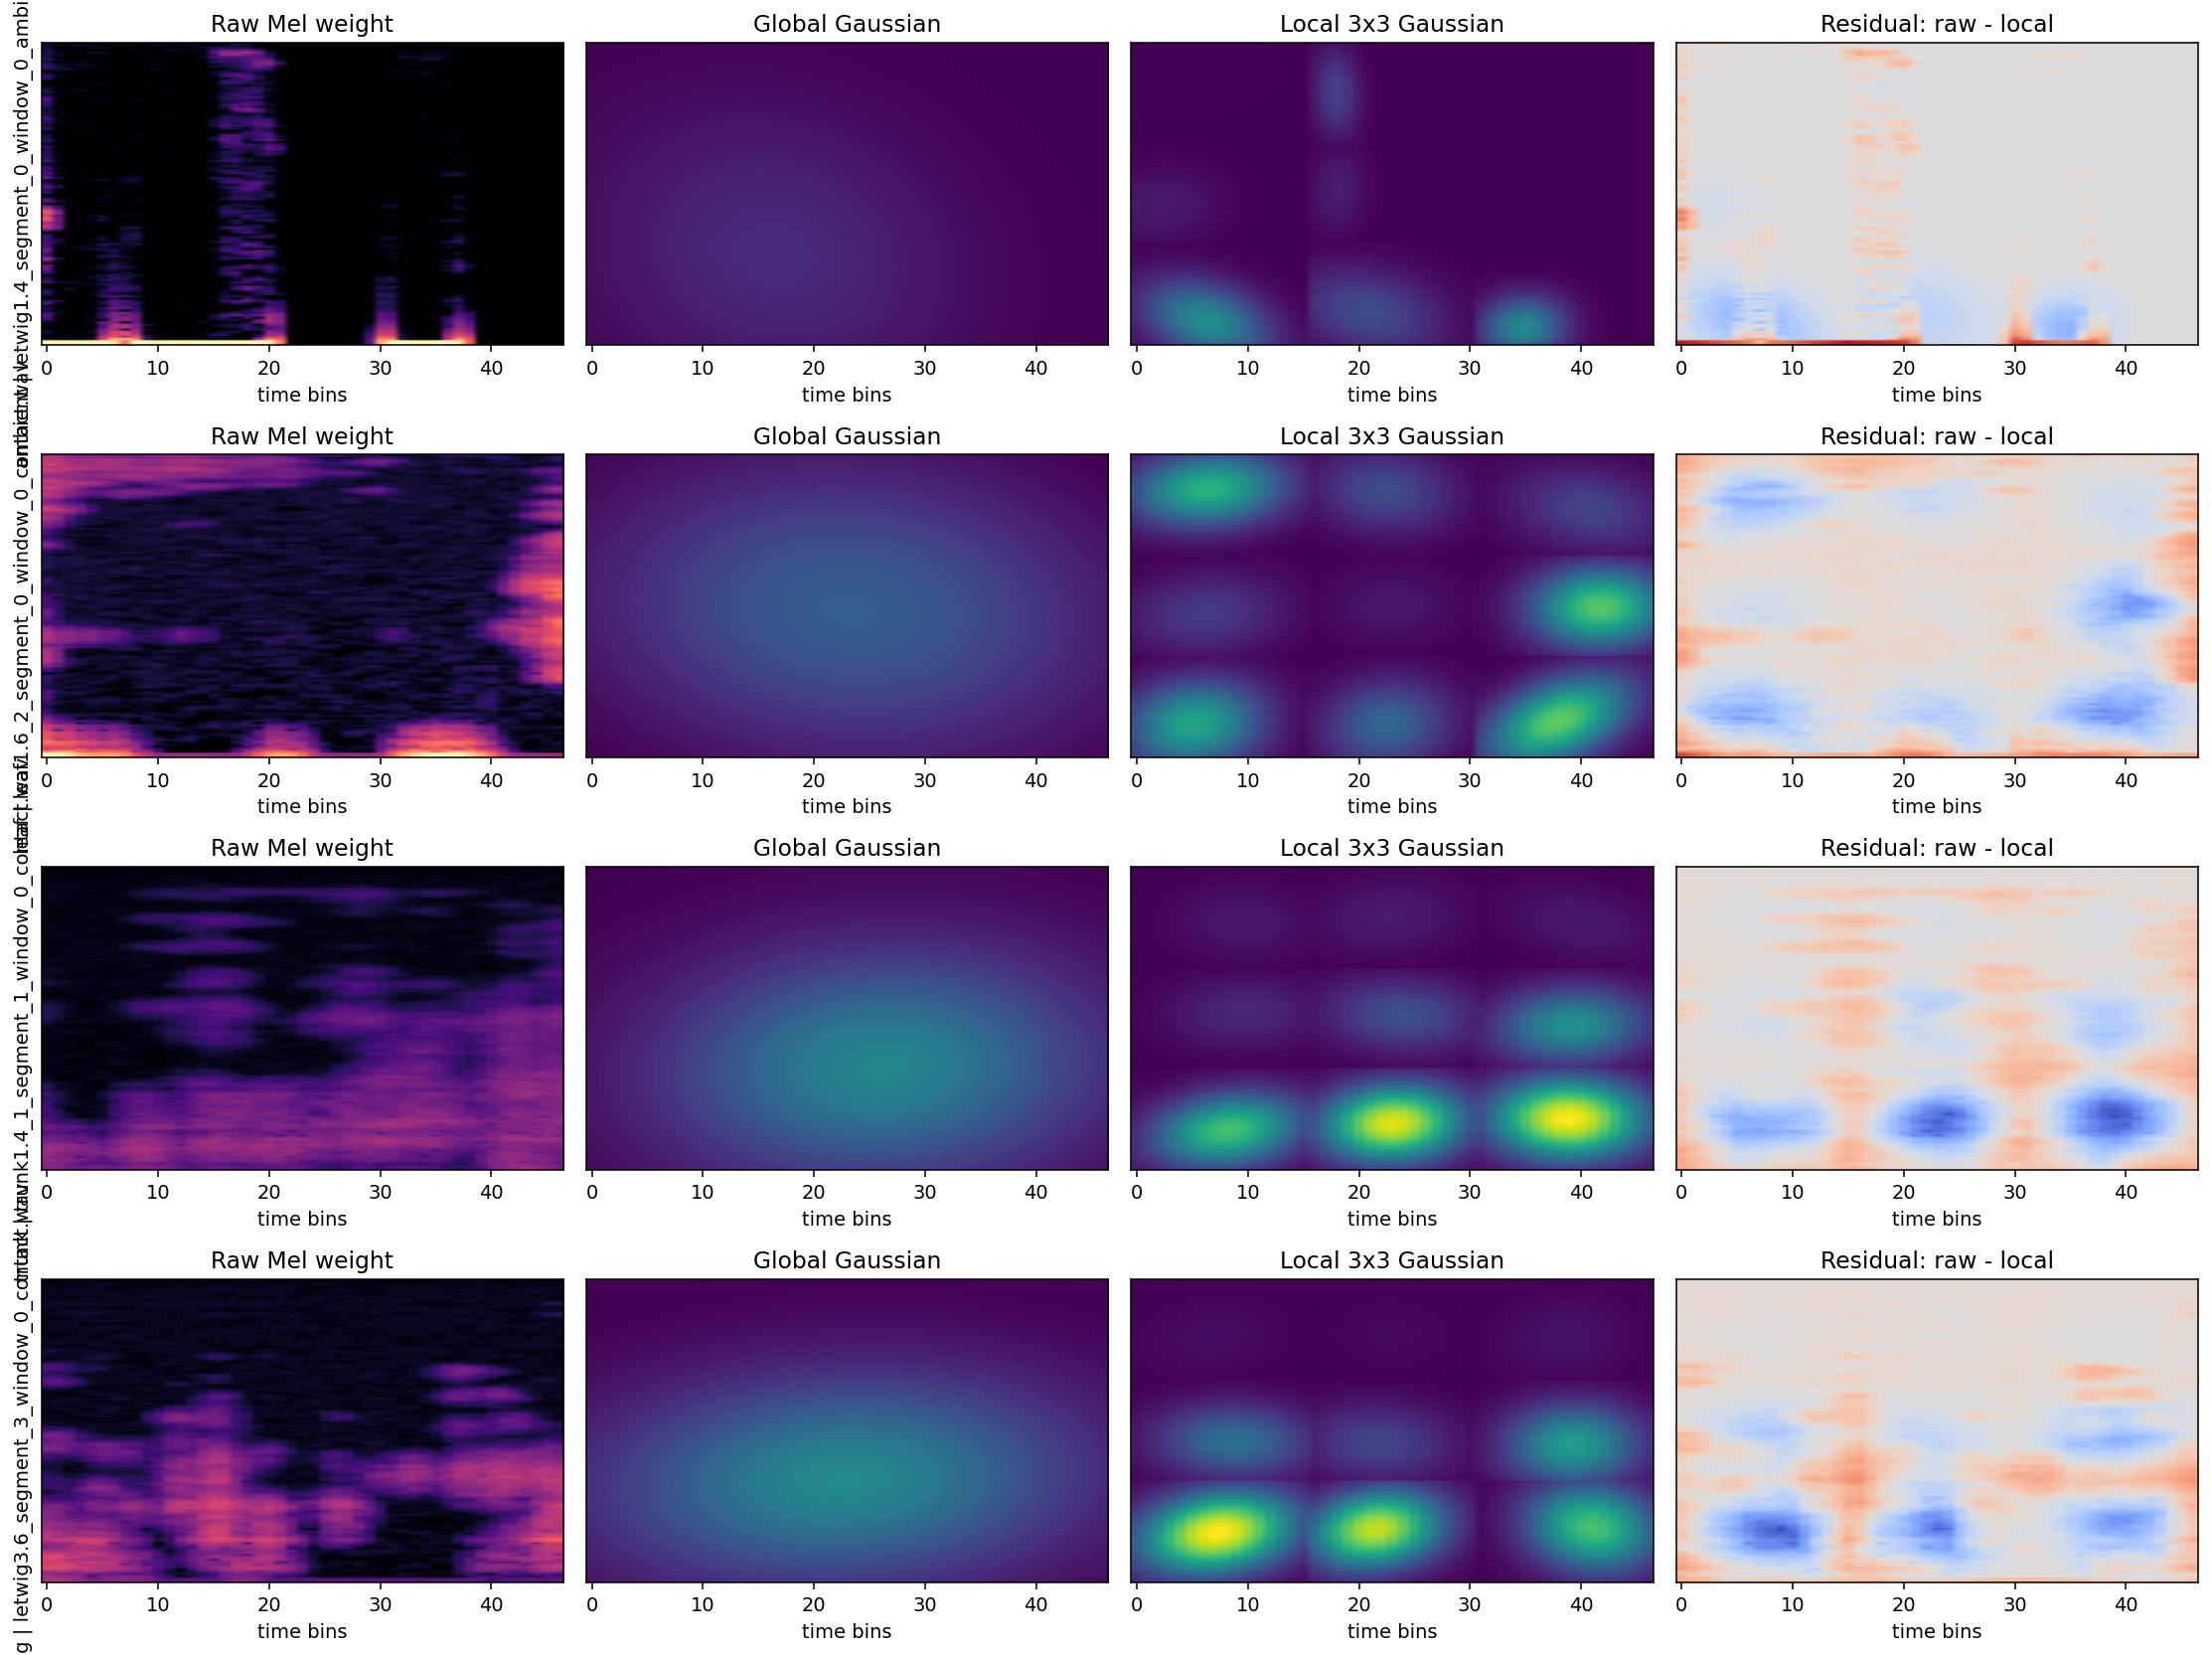

In [6]:
def gaussian_pdf_grid(mu: np.ndarray, cov: np.ndarray, shape: tuple[int, int]) -> np.ndarray:
    n_freq, n_time = shape
    freq = np.linspace(0.0, 1.0, n_freq, dtype=np.float64)
    time = np.linspace(0.0, 1.0, n_time, dtype=np.float64)
    ff, tt = np.meshgrid(freq, time, indexing="ij")
    delta = np.stack([ff - mu[0], tt - mu[1]], axis=-1)
    inv_cov = np.linalg.inv(regularize_cov(cov))
    exponent = np.einsum("...i,ij,...j->...", delta, inv_cov, delta)
    pdf = np.exp(-0.5 * np.clip(exponent, 0.0, 700.0)) + 1e-12
    return pdf / pdf.sum()


def global_gaussian_map(row: pd.Series, shape: tuple[int, int]) -> np.ndarray:
    mu, cov = gaussian_from_row(row, "global")
    return gaussian_pdf_grid(mu, cov, shape)


def local_gaussian_map(row: pd.Series, shape: tuple[int, int], cfg: FeatureConfig) -> np.ndarray:
    output = np.zeros(shape, dtype=np.float64)
    freq_slices = split_slices(shape[0], cfg.local_grid[0])
    time_slices = split_slices(shape[1], cfg.local_grid[1])
    for fi, freq_slice in enumerate(freq_slices):
        for ti, time_slice in enumerate(time_slices):
            prefix = f"local_f{fi}_t{ti}"
            mu, cov = gaussian_from_row(row, prefix)
            patch_shape = (freq_slice.stop - freq_slice.start, time_slice.stop - time_slice.start)
            patch = gaussian_pdf_grid(mu, cov, patch_shape)
            patch_energy = float(row.get(f"{prefix}_energy", 1.0))
            output[freq_slice, time_slice] = patch * max(patch_energy, 1e-12)
    return output / (output.sum() + 1e-12)


def raw_map_for_row(row: pd.Series, cfg: FeatureConfig) -> np.ndarray:
    rng = np.random.default_rng(cfg.seed)
    audio = load_audio_window(row["audio_path"], cfg, rng)
    mel = mel_spectrogram(audio, cfg)
    norm_mel = normalize_map(mel, cfg.normalize_mode)
    return map_to_weights(norm_mel, "positive_shift")


def compare_raw_global_local(features: pd.DataFrame, samples_per_class: int = 1) -> None:
    chosen = []
    for label in LABELS:
        part = features[features["label"] == label]
        if part.empty:
            continue
        chosen.extend(part.head(samples_per_class).to_dict("records"))
    rows = []
    fig, axes = plt.subplots(len(chosen), 4, figsize=(16, max(3.2, 3 * len(chosen))), dpi=140)
    if len(chosen) == 1:
        axes = np.asarray([axes])
    for row_idx, item in enumerate(chosen):
        row = pd.Series(item)
        raw = raw_map_for_row(row, cfg)
        global_map = global_gaussian_map(row, raw.shape)
        local_map = local_gaussian_map(row, raw.shape, cfg)
        residual_global = raw - global_map
        residual_local = raw - local_map
        rows.append(
            {
                "label": row["label"],
                "file": Path(row["audio_path"]).name,
                "global_overlap": float(1.0 - 0.5 * np.abs(residual_global).sum()),
                "local_overlap": float(1.0 - 0.5 * np.abs(residual_local).sum()),
                "global_cosine": float(np.dot(raw.ravel(), global_map.ravel()) / (np.linalg.norm(raw.ravel()) * np.linalg.norm(global_map.ravel()) + 1e-12)),
                "local_cosine": float(np.dot(raw.ravel(), local_map.ravel()) / (np.linalg.norm(raw.ravel()) * np.linalg.norm(local_map.ravel()) + 1e-12)),
            }
        )
        vmax = max(float(raw.max()), float(global_map.max()), float(local_map.max()))
        axes[row_idx, 0].imshow(raw, aspect="auto", origin="lower", cmap="magma", vmax=vmax)
        axes[row_idx, 0].set_title("Raw Mel weight")
        axes[row_idx, 0].set_ylabel(f"{row['label']} | {Path(row['audio_path']).name}")
        axes[row_idx, 1].imshow(global_map, aspect="auto", origin="lower", cmap="viridis", vmax=vmax)
        axes[row_idx, 1].set_title("Global Gaussian")
        axes[row_idx, 2].imshow(local_map, aspect="auto", origin="lower", cmap="viridis", vmax=vmax)
        axes[row_idx, 2].set_title("Local 3x3 Gaussian")
        limit = max(float(np.abs(residual_global).max()), float(np.abs(residual_local).max()))
        axes[row_idx, 3].imshow(residual_local, aspect="auto", origin="lower", cmap="coolwarm", vmin=-limit, vmax=limit)
        axes[row_idx, 3].set_title("Residual: raw - local")
        for ax in axes[row_idx]:
            ax.set_yticks([])
            ax.set_xlabel("time bins")
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "raw_vs_global_vs_local_gaussian.png")
    display(pd.DataFrame(rows).round(4))
    display(fig)
    plt.close(fig)


compare_raw_global_local(features, samples_per_class=1)

In [7]:
if TRAIN_XGBOOST:
    from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
    from xgboost import XGBClassifier

    train = features[features["split_role"] == "train"].reset_index(drop=True)
    val = features[features["split_role"] == "val"].reset_index(drop=True)
    drop_cols = {"split_name", "split_role", "audio_path", "image_path", "label", "label_id"}
    feature_cols = [col for col in features.columns if col not in drop_cols]
    x_train = np.nan_to_num(train[feature_cols].to_numpy(np.float32))
    y_train = train["label_id"].to_numpy()
    x_val = np.nan_to_num(val[feature_cols].to_numpy(np.float32))
    y_val = val["label_id"].to_numpy()
    model = XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="multi:softmax",
        num_class=len(LABELS),
        eval_metric="mlogloss",
        tree_method="hist",
        random_state=SEED,
        n_jobs=-1,
    )
    model.fit(x_train, y_train)
    pred = model.predict(x_val)
    metrics = {
        "accuracy": float(accuracy_score(y_val, pred)),
        "macro_f1": float(f1_score(y_val, pred, average="macro", zero_division=0)),
        "weighted_f1": float(f1_score(y_val, pred, average="weighted", zero_division=0)),
        "confusion_matrix": confusion_matrix(y_val, pred, labels=list(range(len(LABELS)))).tolist(),
        "classification_report": classification_report(
            y_val,
            pred,
            labels=list(range(len(LABELS))),
            target_names=LABELS,
            output_dict=True,
            zero_division=0,
        ),
        "feature_count": len(feature_cols),
    }
    (OUTPUT_DIR / "xgboost_metrics.json").write_text(json.dumps(metrics, indent=2), encoding="utf-8")
    display(metrics)
else:
    print("TRAIN_XGBOOST=False: skipped CPU XGBoost. Use nearest-prototype EDA first, then enable when useful.")

TRAIN_XGBOOST=False: skipped CPU XGBoost. Use nearest-prototype EDA first, then enable when useful.
